# Gold test-set simulation notebook using saved `seed_2` artifacts

This notebook evaluates the model **only on the original official holdout test set**.

It does **not** use the later simulation file.  
That keeps the benchmark aligned with the original study split and lets you compare:

- **official test-set performance**
- **later forward simulation performance**

The workflow here is:

1. Keep the original reported benchmark unchanged.
2. Load the saved `seed_2` model artifacts.
3. Load the original cleaned historical dataset only.
4. Reconstruct the original chronological 80/20 split.
5. Use the exact saved scalers and metadata.
6. Build a date-aligned prediction table for the test set only.
7. Compute RMSE, MAE, and R² on the test set only.
8. Plot actual vs predicted on the test period.
9. Audit dates that are unavailable in the official test forecast range (non-market days, holidays, and other gaps).
10. Let the user enter a `forecast_date` and return either the forecast row or the unavailable-date explanation.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# =========================
# 1) Imports
# =========================
import os
import json
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

try:
    import exchange_calendars as xcals
except Exception:
    xcals = None

warnings.filterwarnings("ignore")

print("TensorFlow version:", tf.__version__)
print("exchange_calendars available:", xcals is not None)


TensorFlow version: 2.19.0
exchange_calendars available: False


In [ ]:
# =========================
# 2) User Inputs
# =========================
BASE_DIR = r"/content/drive/MyDrive/Silver gold Research/Silver gold/ CleanDATA_2026_interpolate/silver_interpolated_plus2_all_seed_models_improved_1cnn_1bilstm(10pm)_norma/seed_0"

# Original cleaned historical dataset used in training / official testing
ORIGINAL_HISTORY_PATH = r"/content/drive/MyDrive/ResearchTestingGold/Silver gold Research/Silver gold/CleanDATA_2026_study_aligned/silver_RRL_interpolate_plus2.csv"

MODEL_METADATA_PATH = os.path.join(BASE_DIR, "model_metadata.pkl")
MODEL_PATH = os.path.join(BASE_DIR, "cnn_bilstm_seed0.keras")
X_SCALER_PATH = os.path.join(BASE_DIR, "x_scaler.pkl")
Y_SCALER_PATH = os.path.join(BASE_DIR, "y_scaler.pkl")

DATE_COL = "Date"
RAW_TARGET_COL = "Silver_Futures"
HORIZON = 1
OUTER_TRAIN_RATIO = 0.80

# Use the same market calendar idea as the uploaded study-aligned acquisition notebook
TARGET_CALENDAR_NAME = "COMEX"

# Manual holiday overrides copied from the uploaded study-aligned acquisition notebook.
# These were included there because exchange_calendars may not surface them consistently.
COMEX_HOLIDAY_MANUAL_OVERRIDES = pd.DataFrame({
    "Date": pd.to_datetime([
        "2022-06-20",
        "2023-06-19",
        "2024-06-19",
    ]),
    "holiday_name": [
        "Juneteenth National Independence Day",
        "Juneteenth National Independence Day",
        "Juneteenth National Independence Day",
    ],
    "holiday_type": [
        "manual_override",
        "manual_override",
        "manual_override",
    ],
    "session_effect": [
        "holiday_schedule_notice",
        "holiday_schedule_notice",
        "holiday_schedule_notice",
    ],
    "close_time": [pd.NaT, pd.NaT, pd.NaT],
    "open_time": [pd.NaT, pd.NaT, pd.NaT],
    "tag_source": [
        "manual_cme_notice",
        "manual_cme_notice",
        "manual_cme_notice",
    ],
    "source_note": [
        "Juneteenth holiday schedule manually added because exchange_calendars did not surface metadata for this date.",
        "Juneteenth holiday schedule manually added because exchange_calendars did not surface metadata for this date.",
        "Juneteenth holiday schedule manually added because exchange_calendars did not surface metadata for this date.",
    ],
})

# Optional: save test predictions table
SAVE_RESULTS = False
RESULTS_CSV_PATH = os.path.join(BASE_DIR, "gold_seed2_official_test_predictions.csv")

# User-input date is asked later in the notebook, so no hardcoded query date is required here.


In [ ]:
# =========================
# 3) Sanity-check paths
# =========================
required_paths = {
    "BASE_DIR": BASE_DIR,
    "ORIGINAL_HISTORY_PATH": ORIGINAL_HISTORY_PATH,
    "MODEL_METADATA_PATH": MODEL_METADATA_PATH,
    "MODEL_PATH": MODEL_PATH,
    "X_SCALER_PATH": X_SCALER_PATH,
}

for name, path in required_paths.items():
    print(f"{name}: {path}")
    if not os.path.exists(path):
        raise FileNotFoundError(f"{name} not found: {path}")

if not os.path.exists(Y_SCALER_PATH):
    print("Note: Y_SCALER_PATH not found. The notebook will continue only if metadata says no y_scaler was saved.")


BASE_DIR: /content/drive/MyDrive/Silver gold Research/Silver gold/ CleanDATA_2026_interpolate/silver_interpolated_plus2_all_seed_models_improved_1cnn_1bilstm(10pm)_norma/seed_0
ORIGINAL_HISTORY_PATH: /content/drive/MyDrive/ResearchTestingGold/Silver gold Research/Silver gold/CleanDATA_2026_study_aligned/silver_RRL_interpolate_plus2.csv
MODEL_METADATA_PATH: /content/drive/MyDrive/Silver gold Research/Silver gold/ CleanDATA_2026_interpolate/silver_interpolated_plus2_all_seed_models_improved_1cnn_1bilstm(10pm)_norma/seed_0/model_metadata.pkl
MODEL_PATH: /content/drive/MyDrive/Silver gold Research/Silver gold/ CleanDATA_2026_interpolate/silver_interpolated_plus2_all_seed_models_improved_1cnn_1bilstm(10pm)_norma/seed_0/cnn_bilstm_seed0.keras
X_SCALER_PATH: /content/drive/MyDrive/Silver gold Research/Silver gold/ CleanDATA_2026_interpolate/silver_interpolated_plus2_all_seed_models_improved_1cnn_1bilstm(10pm)_norma/seed_0/x_scaler.pkl


In [ ]:
# =========================
# 4) Load saved model artifacts
# =========================
with open(MODEL_METADATA_PATH, "rb") as f:
    metadata = pickle.load(f)

with open(X_SCALER_PATH, "rb") as f:
    x_scaler = pickle.load(f)

y_scaler = None
if metadata.get("has_y_scaler", False):
    if not os.path.exists(Y_SCALER_PATH):
        raise FileNotFoundError("Metadata says a y_scaler exists, but y_scaler.pkl was not found.")
    with open(Y_SCALER_PATH, "rb") as f:
        y_scaler = pickle.load(f)

model = tf.keras.models.load_model(MODEL_PATH)

feature_cols = list(metadata["feature_cols"])
MODEL_TARGET_COL = metadata["target_col"]
LOOKBACK = int(metadata["lookback"])

print("Loaded metadata:")
print(json.dumps(
    {
        "feature_cols": feature_cols,
        "target_col": MODEL_TARGET_COL,
        "lookback": LOOKBACK,
        "model_file_in_metadata": metadata.get("model_file"),
        "has_y_scaler": metadata.get("has_y_scaler", False),
    },
    indent=4,
    default=str
))


Loaded metadata:
{
    "feature_cols": [
        "Silver_Futures",
        "Gold_Futures",
        "US30",
        "SnP500",
        "NASDAQ_100",
        "USD_index",
        "T10Y2Y",
        "IGREA"
    ],
    "target_col": "target_t_plus_1",
    "lookback": 12,
    "model_file_in_metadata": "cnn_bilstm_seed0.keras",
    "has_y_scaler": true
}


In [ ]:
# =========================
# 5) Helpers
# =========================
def create_sequences(X_df, y_df, lookback):
    X_values = X_df.values
    y_values = y_df.values.reshape(-1)

    X_seq, y_seq = [], []
    for i in range(lookback, len(X_df)):
        X_seq.append(X_values[i - lookback:i, :])
        y_seq.append(y_values[i])

    return np.array(X_seq), np.array(y_seq)


def create_sequences_with_context(X_prev, y_prev, X_block, y_block, lookback):
    X_full = pd.concat([X_prev.tail(lookback), X_block], axis=0).reset_index(drop=True)
    y_full = pd.concat([y_prev.tail(lookback), y_block], axis=0).reset_index(drop=True)
    return create_sequences(X_full, y_full, lookback)


def inverse_target(arr_1d, y_scaler=None):
    arr_2d = np.asarray(arr_1d).reshape(-1, 1)
    if y_scaler is None:
        return arr_2d.reshape(-1)
    return y_scaler.inverse_transform(arr_2d).reshape(-1)


def _empty_holiday_frame():
    return pd.DataFrame(
        columns=[
            "Date",
            "holiday_name",
            "holiday_type",
            "session_effect",
            "close_time",
            "open_time",
            "tag_source",
            "source_note",
        ]
    )


def build_calendar_holiday_tables(calendar, start_date, end_date, manual_overrides=None):
    start = pd.Timestamp(start_date).normalize()
    end = pd.Timestamp(end_date).normalize()

    def _frames_from_rules(rules, holiday_type, session_effect, close_time=pd.NaT, open_time=pd.NaT):
        frames = []
        for rule in rules:
            rule_dates = pd.DatetimeIndex(rule.dates(start, end))
            if len(rule_dates) == 0:
                continue
            frames.append(pd.DataFrame({
                "Date": rule_dates,
                "holiday_name": getattr(rule, "name", str(rule)),
                "holiday_type": holiday_type,
                "session_effect": session_effect,
                "close_time": close_time,
                "open_time": open_time,
                "tag_source": "exchange_calendars",
                "source_note": "Tagged from exchange_calendars holiday rules.",
            }))
        return frames

    full_frames = []
    regular_holiday_rules = getattr(getattr(calendar, "regular_holidays", None), "rules", [])
    full_frames.extend(
        _frames_from_rules(
            regular_holiday_rules,
            holiday_type="full_closure_regular",
            session_effect="closed",
        )
    )

    adhoc_dates = pd.DatetimeIndex(getattr(calendar, "adhoc_holidays", []))
    if len(adhoc_dates) > 0:
        adhoc_dates = adhoc_dates[(adhoc_dates >= start) & (adhoc_dates <= end)]
        if len(adhoc_dates) > 0:
            full_frames.append(pd.DataFrame({
                "Date": adhoc_dates,
                "holiday_name": "Ad hoc full-closure holiday",
                "holiday_type": "full_closure_adhoc",
                "session_effect": "closed",
                "close_time": pd.NaT,
                "open_time": pd.NaT,
                "tag_source": "exchange_calendars",
                "source_note": "Tagged from exchange_calendars ad hoc holiday list.",
            }))

    full_closures = pd.concat(full_frames, ignore_index=True) if full_frames else _empty_holiday_frame()

    def _special_frames(special_rules, session_effect):
        frames = []
        for tm, holiday_calendar in special_rules:
            rules = getattr(holiday_calendar, "rules", [])
            if rules:
                frames.extend(
                    _frames_from_rules(
                        rules,
                        holiday_type=session_effect,
                        session_effect=session_effect,
                        close_time=str(tm) if session_effect == "special_close" else pd.NaT,
                        open_time=str(tm) if session_effect == "special_open" else pd.NaT,
                    )
                )
            else:
                cal_dates = pd.DatetimeIndex(holiday_calendar.holidays(start, end))
                if len(cal_dates) == 0:
                    continue
                frames.append(pd.DataFrame({
                    "Date": cal_dates,
                    "holiday_name": f"{session_effect} holiday",
                    "holiday_type": session_effect,
                    "session_effect": session_effect,
                    "close_time": str(tm) if session_effect == "special_close" else pd.NaT,
                    "open_time": str(tm) if session_effect == "special_open" else pd.NaT,
                    "tag_source": "exchange_calendars",
                    "source_note": "Tagged from exchange_calendars special session rules.",
                }))
        return frames

    special_close_frames = _special_frames(getattr(calendar, "special_closes", []), "special_close")
    special_open_frames = _special_frames(getattr(calendar, "special_opens", []), "special_open")

    special_closes = pd.concat(special_close_frames, ignore_index=True) if special_close_frames else _empty_holiday_frame()
    special_opens = pd.concat(special_open_frames, ignore_index=True) if special_open_frames else _empty_holiday_frame()

    manual_df = _empty_holiday_frame()
    if manual_overrides is not None and len(manual_overrides) > 0:
        manual_df = manual_overrides.copy()
        manual_df["Date"] = pd.to_datetime(manual_df["Date"]).dt.normalize()
        manual_df = manual_df[(manual_df["Date"] >= start) & (manual_df["Date"] <= end)]

    holiday_schedule = pd.concat(
        [full_closures, special_closes, special_opens, manual_df],
        ignore_index=True
    )
    if not holiday_schedule.empty:
        holiday_schedule["Date"] = pd.to_datetime(holiday_schedule["Date"]).dt.normalize()
        holiday_schedule = (
            holiday_schedule
            .sort_values(["Date", "holiday_type", "holiday_name"])
            .drop_duplicates(subset=["Date", "holiday_type", "holiday_name"])
            .reset_index(drop=True)
        )

    return full_closures, special_closes, special_opens, manual_df, holiday_schedule


def nearest_available_dates(query_date, available_dates):
    available_idx = pd.DatetimeIndex(pd.to_datetime(available_dates)).normalize().sort_values().unique()
    query_date = pd.Timestamp(query_date).normalize()

    prev_dates = available_idx[available_idx < query_date]
    next_dates = available_idx[available_idx > query_date]

    prev_date = prev_dates.max() if len(prev_dates) else pd.NaT
    next_date = next_dates.min() if len(next_dates) else pd.NaT
    return prev_date, next_date


def build_unavailable_forecast_dates(available_forecast_dates, start_date, end_date, calendar_name="COMEX", manual_overrides=None):
    start = pd.Timestamp(start_date).normalize()
    end = pd.Timestamp(end_date).normalize()
    available_idx = pd.DatetimeIndex(pd.to_datetime(available_forecast_dates)).normalize().sort_values().unique()
    daily_range = pd.date_range(start, end, freq="D")
    unavailable_idx = daily_range.difference(available_idx)

    rows = []
    holiday_schedule = _empty_holiday_frame()
    calendar_sessions = None

    if xcals is not None:
        calendar = xcals.get_calendar(calendar_name)
        calendar_sessions = pd.DatetimeIndex(calendar.sessions_in_range(start, end)).normalize()
        _, _, _, _, holiday_schedule = build_calendar_holiday_tables(
            calendar,
            start,
            end,
            manual_overrides=manual_overrides,
        )
        if not holiday_schedule.empty:
            holiday_schedule["Date"] = pd.to_datetime(holiday_schedule["Date"]).dt.normalize()

    for dt in unavailable_idx:
        dt = pd.Timestamp(dt).normalize()
        prev_date, next_date = nearest_available_dates(dt, available_idx)

        schedule_rows = pd.DataFrame()
        if not holiday_schedule.empty:
            schedule_rows = holiday_schedule.loc[holiday_schedule["Date"] == dt].copy()

        if calendar_sessions is None:
            if dt.dayofweek >= 5:
                market_status = "non-market day"
                reason = "Weekend / not available in dataset"
            else:
                market_status = "not available in dataset"
                reason = "Date not present in official forecast table"
        else:
            is_session = dt in calendar_sessions
            if not is_session:
                market_status = "non-market day"
                if not schedule_rows.empty:
                    reason = " | ".join(
                        schedule_rows["holiday_name"].astype(str) + " (" + schedule_rows["session_effect"].astype(str) + ")"
                    )
                elif dt.dayofweek >= 5:
                    reason = "Weekend / COMEX closed"
                else:
                    reason = "COMEX closed / no market session"
            else:
                market_status = "calendar session but unavailable in dataset"
                if not schedule_rows.empty:
                    reason = " | ".join(
                        schedule_rows["holiday_name"].astype(str) + " (" + schedule_rows["session_effect"].astype(str) + ")"
                    ) + " | date still unavailable in dataset"
                else:
                    reason = "Valid COMEX session but missing from official forecast table"

        rows.append({
            "Date": dt,
            "market_status": market_status,
            "reason": reason,
            "nearest_previous_available_forecast": prev_date,
            "nearest_next_available_forecast": next_date,
        })

    unavailable_df = pd.DataFrame(rows).sort_values("Date").reset_index(drop=True)
    return unavailable_df


In [ ]:
# =========================
# 6) Load and preprocess the original historical dataframe
# =========================
df_raw = pd.read_csv(ORIGINAL_HISTORY_PATH)

if RAW_TARGET_COL not in df_raw.columns:
    raise ValueError(f"RAW_TARGET_COL '{RAW_TARGET_COL}' is not present in the dataframe.")

if DATE_COL not in df_raw.columns:
    raise ValueError(f"DATE_COL '{DATE_COL}' is not present in the dataframe.")

df_raw[DATE_COL] = pd.to_datetime(df_raw[DATE_COL], errors="coerce")
df_raw = df_raw.dropna(subset=[DATE_COL]).sort_values(DATE_COL).reset_index(drop=True)
df_raw = df_raw.set_index(DATE_COL)

# Keep numeric columns exactly as in training preprocessing
df_raw[RAW_TARGET_COL] = pd.to_numeric(df_raw[RAW_TARGET_COL], errors="coerce")
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()

if RAW_TARGET_COL not in numeric_cols:
    raise ValueError(f"RAW_TARGET_COL '{RAW_TARGET_COL}' must be numeric.")

df = df_raw[numeric_cols].copy()

# Build the shifted one-step-ahead target exactly like training
df[MODEL_TARGET_COL] = df[RAW_TARGET_COL].shift(-HORIZON)

# Keep a forecast-date column for date-aligned reporting
df["forecast_date"] = pd.Series(df.index, index=df.index).shift(-HORIZON)

# Clean invalid rows
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=[MODEL_TARGET_COL, "forecast_date"]).copy()

# Check required feature columns from metadata
missing_features = [c for c in feature_cols if c not in df.columns]
if missing_features:
    raise ValueError(f"Missing required feature columns from metadata: {missing_features}")

print("Processed dataframe shape:", df.shape)
display(df.head())
display(df.tail())


Processed dataframe shape: (2545, 10)


,Silver_Futures,Gold_Futures,US30,SnP500,NASDAQ_100,USD_index,T10Y2Y,IGREA,target_t_plus_1,forecast_date
Date,,,,,,,,,,
2015-04-01,17.059,1208.2,17698.2,2059.7,4311.26,98.190002,1.32,-96.726032,16.701,2015-04-02
2015-04-02,16.701,1200.9,17763.2,2067.0,4316.01,97.440002,1.37,-96.699724,17.110,2015-04-06
2015-04-06,17.110,1218.6,17880.8,2080.6,4350.98,97.110001,1.41,-96.594492,16.840,2015-04-07
2015-04-07,16.840,1210.6,17875.4,2076.3,4344.08,97.830002,1.37,-96.568184,16.454,2015-04-08
2015-04-08,16.454,1203.1,17902.5,2081.9,4375.96,98.070000,1.38,-96.541876,16.176,2015-04-09


,Silver_Futures,Gold_Futures,US30,SnP500,NASDAQ_100,USD_index,T10Y2Y,IGREA,target_t_plus_1,forecast_date
Date,,,,,,,,,,
2025-04-23,33.547000,3294.100000,39577.5,5375.86,18693.26,99.72,0.59,-23.563474,33.503000,2025-04-24
2025-04-24,33.503000,3348.600000,40069.0,5484.77,19214.40,99.31,0.55,-23.563474,32.988998,2025-04-25
2025-04-25,32.988998,3282.399902,40126.5,5525.21,19432.56,99.58,0.55,-23.563474,33.165000,2025-04-28
2025-04-28,33.165000,3333.000000,40255.0,5528.75,19427.29,99.01,0.56,-23.563474,33.577000,2025-04-29
2025-04-29,33.577000,3333.600000,40520.0,5560.83,19544.95,99.14,0.54,-23.563474,32.828000,2025-04-30


In [ ]:
# =========================
# 7) Reconstruct the original official chronological split
# =========================
split_idx = int(len(df) * OUTER_TRAIN_RATIO)

df_train_outer = df.iloc[:split_idx].copy()
df_test = df.iloc[split_idx:].copy()

print("Train shape:", df_train_outer[feature_cols].shape)
print("Test shape:", df_test[feature_cols].shape)

print("Train anchor date range:", df_train_outer.index.min(), "to", df_train_outer.index.max())
print("Test anchor date range:", df_test.index.min(), "to", df_test.index.max())

print("Train forecast date range:", df_train_outer["forecast_date"].min(), "to", df_train_outer["forecast_date"].max())
print("Test forecast date range:", df_test["forecast_date"].min(), "to", df_test["forecast_date"].max())


Train shape: (2036, 8)
Test shape: (509, 8)
Train anchor date range: 2015-04-01 00:00:00 to 2023-04-18 00:00:00
Test anchor date range: 2023-04-19 00:00:00 to 2025-04-29 00:00:00
Train forecast date range: 2015-04-02 00:00:00 to 2023-04-19 00:00:00
Test forecast date range: 2023-04-20 00:00:00 to 2025-04-30 00:00:00


In [ ]:
# =========================
# 8) Prepare train-tail context and official test-set sequences
# =========================
X_train_outer_raw = df_train_outer[feature_cols].copy()
y_train_outer_raw = df_train_outer[[MODEL_TARGET_COL]].copy()

X_test_raw = df_test[feature_cols].copy()
y_test_raw = df_test[[MODEL_TARGET_COL]].copy()

# Use the exact saved scalers. Do not refit.
X_train_outer_scaled = pd.DataFrame(
    x_scaler.transform(X_train_outer_raw),
    columns=feature_cols
)

X_test_scaled = pd.DataFrame(
    x_scaler.transform(X_test_raw),
    columns=feature_cols
)

if y_scaler is not None:
    y_train_outer_scaled = pd.DataFrame(
        y_scaler.transform(y_train_outer_raw),
        columns=[MODEL_TARGET_COL]
    )
    y_test_scaled = pd.DataFrame(
        y_scaler.transform(y_test_raw),
        columns=[MODEL_TARGET_COL]
    )
else:
    y_train_outer_scaled = y_train_outer_raw.reset_index(drop=True).copy()
    y_test_scaled = y_test_raw.reset_index(drop=True).copy()

X_test_seq, y_test_seq = create_sequences_with_context(
    X_train_outer_scaled,
    y_train_outer_scaled,
    X_test_scaled,
    y_test_scaled,
    LOOKBACK
)

print("Official test sequences:", X_test_seq.shape, y_test_seq.shape)

if len(X_test_seq) != len(df_test):
    raise ValueError(
        f"Sequence count mismatch: len(X_test_seq)={len(X_test_seq)} but len(df_test)={len(df_test)}"
    )


Official test sequences: (509, 12, 8) (509,)


In [ ]:
# =========================
# 9) Predict on the official holdout test set only
# =========================
y_pred_test_scaled = model.predict(X_test_seq, verbose=0).reshape(-1)

y_pred_test = inverse_target(y_pred_test_scaled, y_scaler=y_scaler)
y_true_test = df_test[MODEL_TARGET_COL].values.reshape(-1)

test_results = pd.DataFrame({
    "anchor_date": df_test.index,
    "forecast_date": pd.to_datetime(df_test["forecast_date"]).values,
    "predicted_price": y_pred_test,
    "actual_price": y_true_test,
})

test_results["error"] = test_results["actual_price"] - test_results["predicted_price"]
test_results["abs_error"] = np.abs(test_results["error"])

display(test_results.head())
display(test_results.tail())


,anchor_date,forecast_date,predicted_price,actual_price,error,abs_error
0,2023-04-19,2023-04-20,24.672974,25.478000,0.805026,0.805026
1,2023-04-20,2023-04-21,24.747694,25.052999,0.305305,0.305305
2,2023-04-21,2023-04-24,24.778399,25.411000,0.632601,0.632601
3,2023-04-24,2023-04-25,24.721045,24.978000,0.256955,0.256955
4,2023-04-25,2023-04-26,24.752787,24.972000,0.219213,0.219213


,anchor_date,forecast_date,predicted_price,actual_price,error,abs_error
504,2025-04-23,2025-04-24,34.864273,33.503000,-1.361273,1.361273
505,2025-04-24,2025-04-25,35.314648,32.988998,-2.325649,2.325649
506,2025-04-25,2025-04-28,35.758083,33.165000,-2.593083,2.593083
507,2025-04-28,2025-04-29,35.974789,33.577000,-2.397789,2.397789
508,2025-04-29,2025-04-30,36.189484,32.828000,-3.361484,3.361484


In [ ]:
# =========================
# 10) Compute official test-set metrics
# =========================
rmse = float(np.sqrt(mean_squared_error(test_results["actual_price"], test_results["predicted_price"])))
mae = float(mean_absolute_error(test_results["actual_price"], test_results["predicted_price"]))
r2 = float(r2_score(test_results["actual_price"], test_results["predicted_price"]))

metrics = {
    "rows": int(len(test_results)),
    "rmse": rmse,
    "mae": mae,
    "r2": r2,
}

print(json.dumps(metrics, indent=4))


{
    "rows": 509,
    "rmse": 1.2078758050106664,
    "mae": 0.9113516247042973,
    "r2": 0.9037322420603106
}


In [ ]:
# =========================
# 10B) Audit dates that are unavailable in the official forecast table
# =========================
forecast_start = pd.to_datetime(test_results["forecast_date"]).min().normalize()
forecast_end = pd.to_datetime(test_results["forecast_date"]).max().normalize()

unavailable_forecast_dates = build_unavailable_forecast_dates(
    available_forecast_dates=test_results["forecast_date"],
    start_date=forecast_start,
    end_date=forecast_end,
    calendar_name=TARGET_CALENDAR_NAME,
    manual_overrides=COMEX_HOLIDAY_MANUAL_OVERRIDES,
)

print("Official forecast date range:")
print(forecast_start, "to", forecast_end)
print("Available forecast rows:", len(test_results))
print("Unavailable dates inside the forecast range:", len(unavailable_forecast_dates))

display(unavailable_forecast_dates.head(20))
display(unavailable_forecast_dates.tail(20))

# Optional quick summary by reason/status
if len(unavailable_forecast_dates):
    print("Unavailable-date summary by market_status:")
    display(unavailable_forecast_dates["market_status"].value_counts(dropna=False).to_frame("count"))

    print("Top unavailable-date reasons:")
    display(unavailable_forecast_dates["reason"].value_counts(dropna=False).head(15).to_frame("count"))


Official forecast date range:
2023-04-20 00:00:00 to 2025-04-30 00:00:00
Available forecast rows: 509
Unavailable dates inside the forecast range: 233


,Date,market_status,reason,nearest_previous_available_forecast,nearest_next_available_forecast
0,2023-04-22,non-market day,Weekend / not available in dataset,2023-04-21,2023-04-24
1,2023-04-23,non-market day,Weekend / not available in dataset,2023-04-21,2023-04-24
2,2023-04-29,non-market day,Weekend / not available in dataset,2023-04-28,2023-05-01
3,2023-04-30,non-market day,Weekend / not available in dataset,2023-04-28,2023-05-01
4,2023-05-06,non-market day,Weekend / not available in dataset,2023-05-05,2023-05-08
5,2023-05-07,non-market day,Weekend / not available in dataset,2023-05-05,2023-05-08
6,2023-05-13,non-market day,Weekend / not available in dataset,2023-05-12,2023-05-15
7,2023-05-14,non-market day,Weekend / not available in dataset,2023-05-12,2023-05-15
8,2023-05-20,non-market day,Weekend / not available in dataset,2023-05-19,2023-05-22
9,2023-05-21,non-market day,Weekend / not available in dataset,2023-05-19,2023-05-22


,Date,market_status,reason,nearest_previous_available_forecast,nearest_next_available_forecast
213,2025-02-23,non-market day,Weekend / not available in dataset,2025-02-21,2025-02-24
214,2025-03-01,non-market day,Weekend / not available in dataset,2025-02-28,2025-03-03
215,2025-03-02,non-market day,Weekend / not available in dataset,2025-02-28,2025-03-03
216,2025-03-08,non-market day,Weekend / not available in dataset,2025-03-07,2025-03-10
217,2025-03-09,non-market day,Weekend / not available in dataset,2025-03-07,2025-03-10
218,2025-03-15,non-market day,Weekend / not available in dataset,2025-03-14,2025-03-17
219,2025-03-16,non-market day,Weekend / not available in dataset,2025-03-14,2025-03-17
220,2025-03-22,non-market day,Weekend / not available in dataset,2025-03-21,2025-03-24
221,2025-03-23,non-market day,Weekend / not available in dataset,2025-03-21,2025-03-24
222,2025-03-29,non-market day,Weekend / not available in dataset,2025-03-28,2025-03-31


Unavailable-date summary by market_status:


,count
market_status,
non-market day,212
not available in dataset,21


Top unavailable-date reasons:


,count
reason,
Weekend / not available in dataset,212
Date not present in official forecast table,21


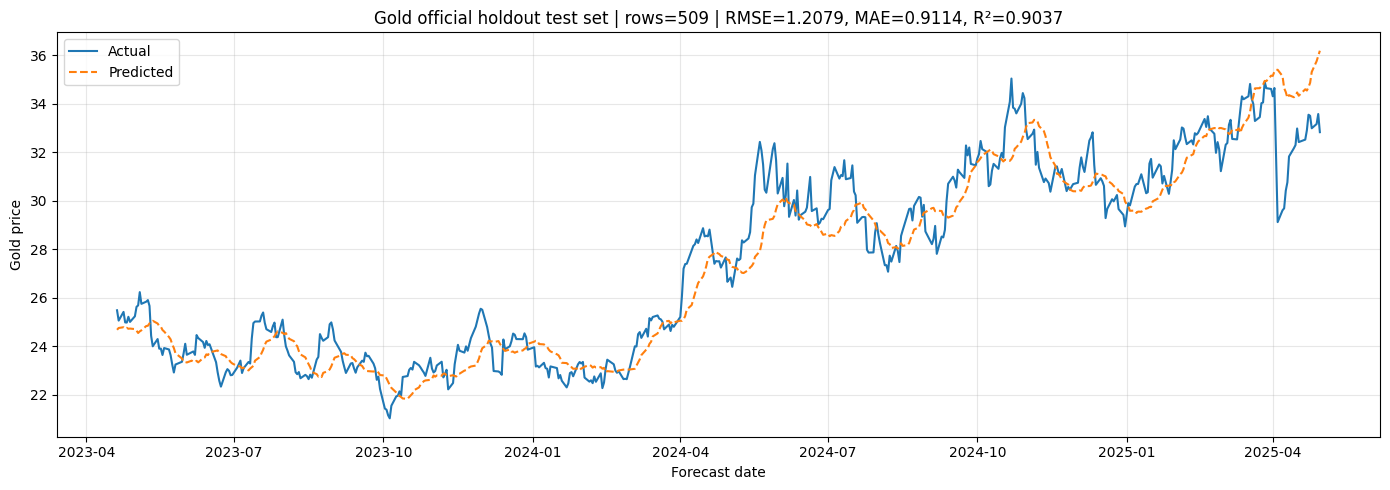

In [ ]:
# =========================
# 11) Plot actual vs predicted on the official test period
# =========================
plt.figure(figsize=(14, 5))
plt.plot(test_results["forecast_date"], test_results["actual_price"], label="Actual")
plt.plot(test_results["forecast_date"], test_results["predicted_price"], linestyle="--", label="Predicted")

plt.title(
    f"Gold official holdout test set | rows={len(test_results)} | "
    f"RMSE={rmse:.4f}, MAE={mae:.4f}, R²={r2:.4f}"
)
plt.xlabel("Forecast date")
plt.ylabel("Gold price")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# =========================
# 12) Optional: save the test prediction table
# =========================
if SAVE_RESULTS:
    test_results.to_csv(RESULTS_CSV_PATH, index=False)
    print("Saved:", RESULTS_CSV_PATH)
else:
    print("SAVE_RESULTS is False. No CSV was written.")


SAVE_RESULTS is False. No CSV was written.


In [ ]:
# =========================
# User-input forecast-date lookup
# =========================
forecast_min = pd.to_datetime(test_results["forecast_date"]).min().normalize()
forecast_max = pd.to_datetime(test_results["forecast_date"]).max().normalize()

print("Available forecast date range:")
print(forecast_min, "to", forecast_max)

user_date_str = input("Enter forecast date (YYYY-MM-DD): ").strip()
query_date = pd.to_datetime(user_date_str, errors="coerce")

if pd.isna(query_date):
    print("Invalid date format. Please enter the date as YYYY-MM-DD.")
else:
    query_date = pd.Timestamp(query_date).normalize()
    picked = test_results[test_results["forecast_date"] == query_date].copy()

    if picked.empty:
        print(f"No forecast row found for {query_date.date()}.")

        if query_date < forecast_min or query_date > forecast_max:
            print("That date is outside the official forecast range shown above.")
            prev_date, next_date = nearest_available_dates(query_date, test_results["forecast_date"])
            print("Nearest available forecast dates:")
            print("Previous:", prev_date)
            print("Next:    ", next_date)
        else:
            unavailable_match = unavailable_forecast_dates.loc[
                unavailable_forecast_dates["Date"] == query_date
            ].copy()

            if unavailable_match.empty:
                print("The date is inside the official range but is not present in the forecast table.")
                prev_date, next_date = nearest_available_dates(query_date, test_results["forecast_date"])
                print("Nearest available forecast dates:")
                print("Previous:", prev_date)
                print("Next:    ", next_date)
            else:
                print("Unavailable-date explanation:")
                display(unavailable_match)

    else:
        picked = picked.copy()
        picked["absolute_error"] = (picked["actual_price"] - picked["predicted_price"]).abs()
        picked["squared_error"] = (picked["actual_price"] - picked["predicted_price"]) ** 2
        one_step_rmse = picked["squared_error"].pow(0.5).iloc[0]

        print(f"\nForecast result for {query_date.date()}:")
        display(
            picked[
                [
                    "anchor_date",
                    "forecast_date",
                    "predicted_price",
                    "actual_price",
                    "absolute_error",
                    "squared_error",
                ]
            ]
        )

        print("\nOverall official test-set performance:")
        print(f"RMSE: {rmse:.6f}")
        print(f"R²:   {r2:.6f}")
        print(f"One-step RMSE: {one_step_rmse:.6f}")


Available forecast date range:
2023-04-20 00:00:00 to 2025-04-30 00:00:00
Enter forecast date (YYYY-MM-DD): 2023-05-4

Forecast result for 2023-05-04:


,anchor_date,forecast_date,predicted_price,actual_price,absolute_error,squared_error
10,2023-05-03,2023-05-04,24.609707,26.227,1.617293,2.615637



Overall official test-set performance:
RMSE: 1.207876
R²:   0.903732
One-step RMSE: 1.617293


## How to interpret this notebook

- This notebook measures performance only on the **official original test set**.
- It is the cleanest notebook to use when you want to reproduce the **reported holdout-test behavior**.
- It is **not** the same as the later forward simulation on 2025-05-01 onward.
- It now also audits **dates that are unavailable** inside the official forecast range.
- Those unavailable dates are tagged using the same **COMEX calendar idea** and **manual Juneteenth overrides** used in the uploaded study-aligned data-acquisition notebook.
- If the official test-set performance is good but the later simulation is poor, that supports the conclusion that the model fit the original split better than it generalized forward in time.
